# Parsivel2

The OTT Parsivel2 is a laser-based disdrometer for comprehensive measurement of all types of precipitation. There are currently 3 such disdrometers in operation at the BCO.

In [1]:
from datetime import datetime
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress
import xarray as xr

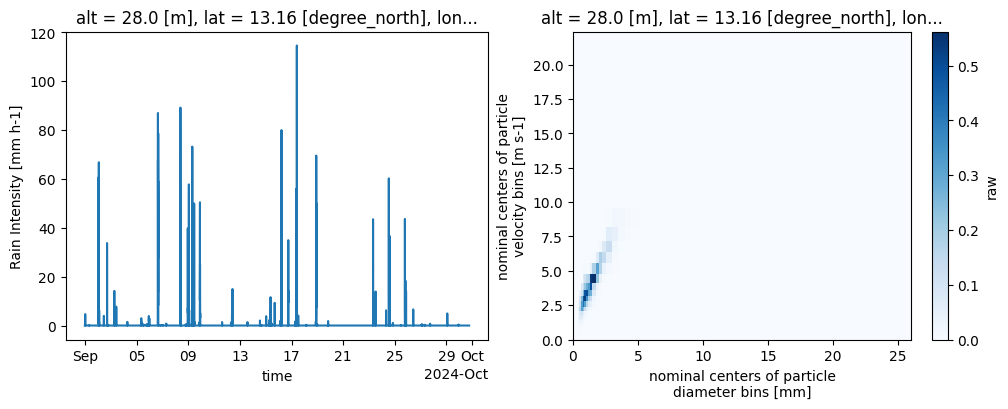

In [2]:
import intake
import matplotlib.pylab as plt
cat = intake.open_catalog("https://tcodata.mpimet.mpg.de/catalog.yaml")
ds = cat.BCO.disdrometer_PARSIVEL451995_c1.to_dask()
subset = ds.sel(time="2024-09")
fix, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
subset["rain_rate"].plot(ax=ax1)
subset["raw"].mean("time").plot(cmap="Blues", ax=ax2);

# Data Availability
- The data from the first parsivel is available as `BCO.disdrometer_PARSIVEL451995_c1` in the catalog.
- The next two are published under the keys `BCO.disdrometer_PARSIVEL451996_c1_v2` and `BCO.disdrometer_PARSIVEL451997_c1_v2`.
- The WXT surfacemet instrument will also be used.
- We will load these datasets and have a look at them.

In [3]:
ds1 = cat.BCO.disdrometer_PARSIVEL451995_c1.to_dask()
ds2 = cat.BCO.disdrometer_PARSIVEL451996_c1_v2.to_dask()
ds3 = cat.BCO.disdrometer_PARSIVEL451997_c1_v2.to_dask()
wxt = cat.BCO.surfacemet_wxt_v1.to_dask()

In [27]:
wxt['time'].diff('time')

<xarray.DataArray 'time' (time: 43986399)> Size: 352MB
array([10000000000, 10000000000, 10000000000, ..., 10000000000,
       10000000000, 10000000000], dtype='timedelta64[ns]')
Coordinates:
    alt      float64 8B ...
    lat      float64 8B ...
    lon      float64 8B ...
  * time     (time) datetime64[ns] 352MB 2010-12-16T16:24:10 ... 2026-05-07T2...

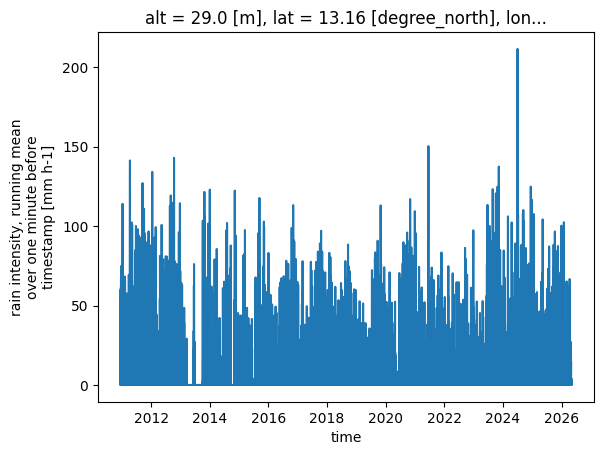

In [4]:
wxt['RI'].plot()

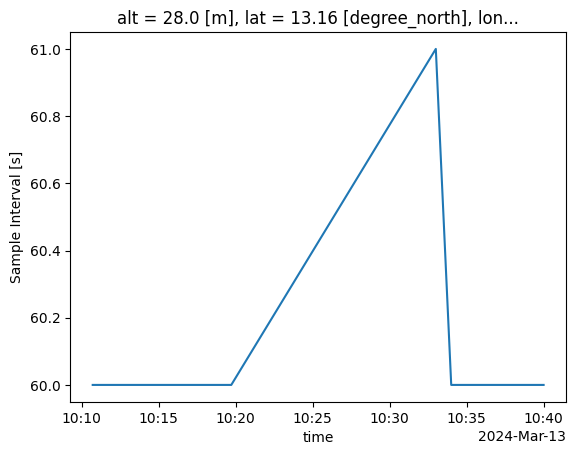

In [13]:
# ds1['sample_interval'].sel(time=slice('2024-03', '2024-05')).plot()
# ds1['sample_interval'].sel(time='2024-04-03').plot()
ds1['sample_interval'].sel(time=slice('2024-03-13T10:10', '2024-03-13T10:40')).plot()

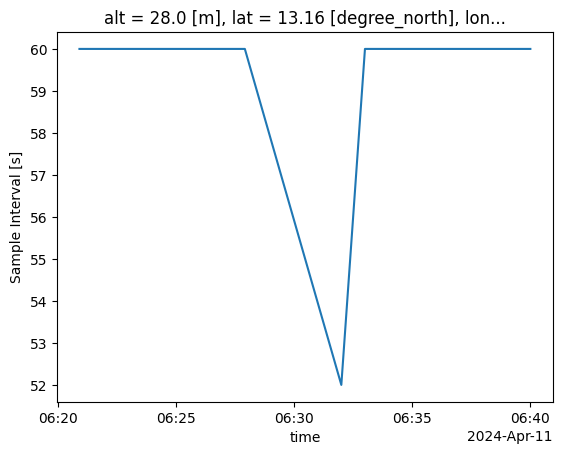

In [14]:
ds1['sample_interval'].sel(time=slice('2024-04-11T6:20', '2024-04-11T6:40')).plot()

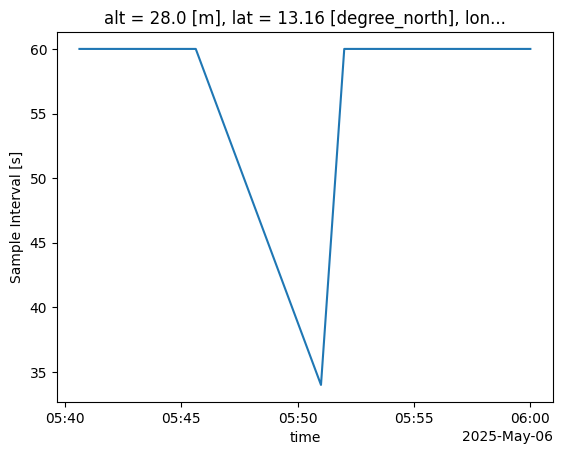

In [15]:
ds1['sample_interval'].sel(time=slice('2025-05-06T05:40', '2025-05-06T06:00')).plot()

In [34]:
ds1['sensor_status'].plot()

In [6]:
ds1_rain_rate = ds1['rain_rate'].sel(time=slice('2023-05-14T00:46:28', datetime.now())).compute()
ds2_rain_rate = ds2['rain_rate'].sel(time=slice('2023-05-14T00:46:28', datetime.now())).compute()
ds3_rain_rate = ds3['rain_rate'].sel(time=slice('2023-05-14T00:46:28', datetime.now())).compute()
wxt_rain = wxt['R'].sel(time=slice('2023-05-14T00:46:28', datetime.now())).compute()

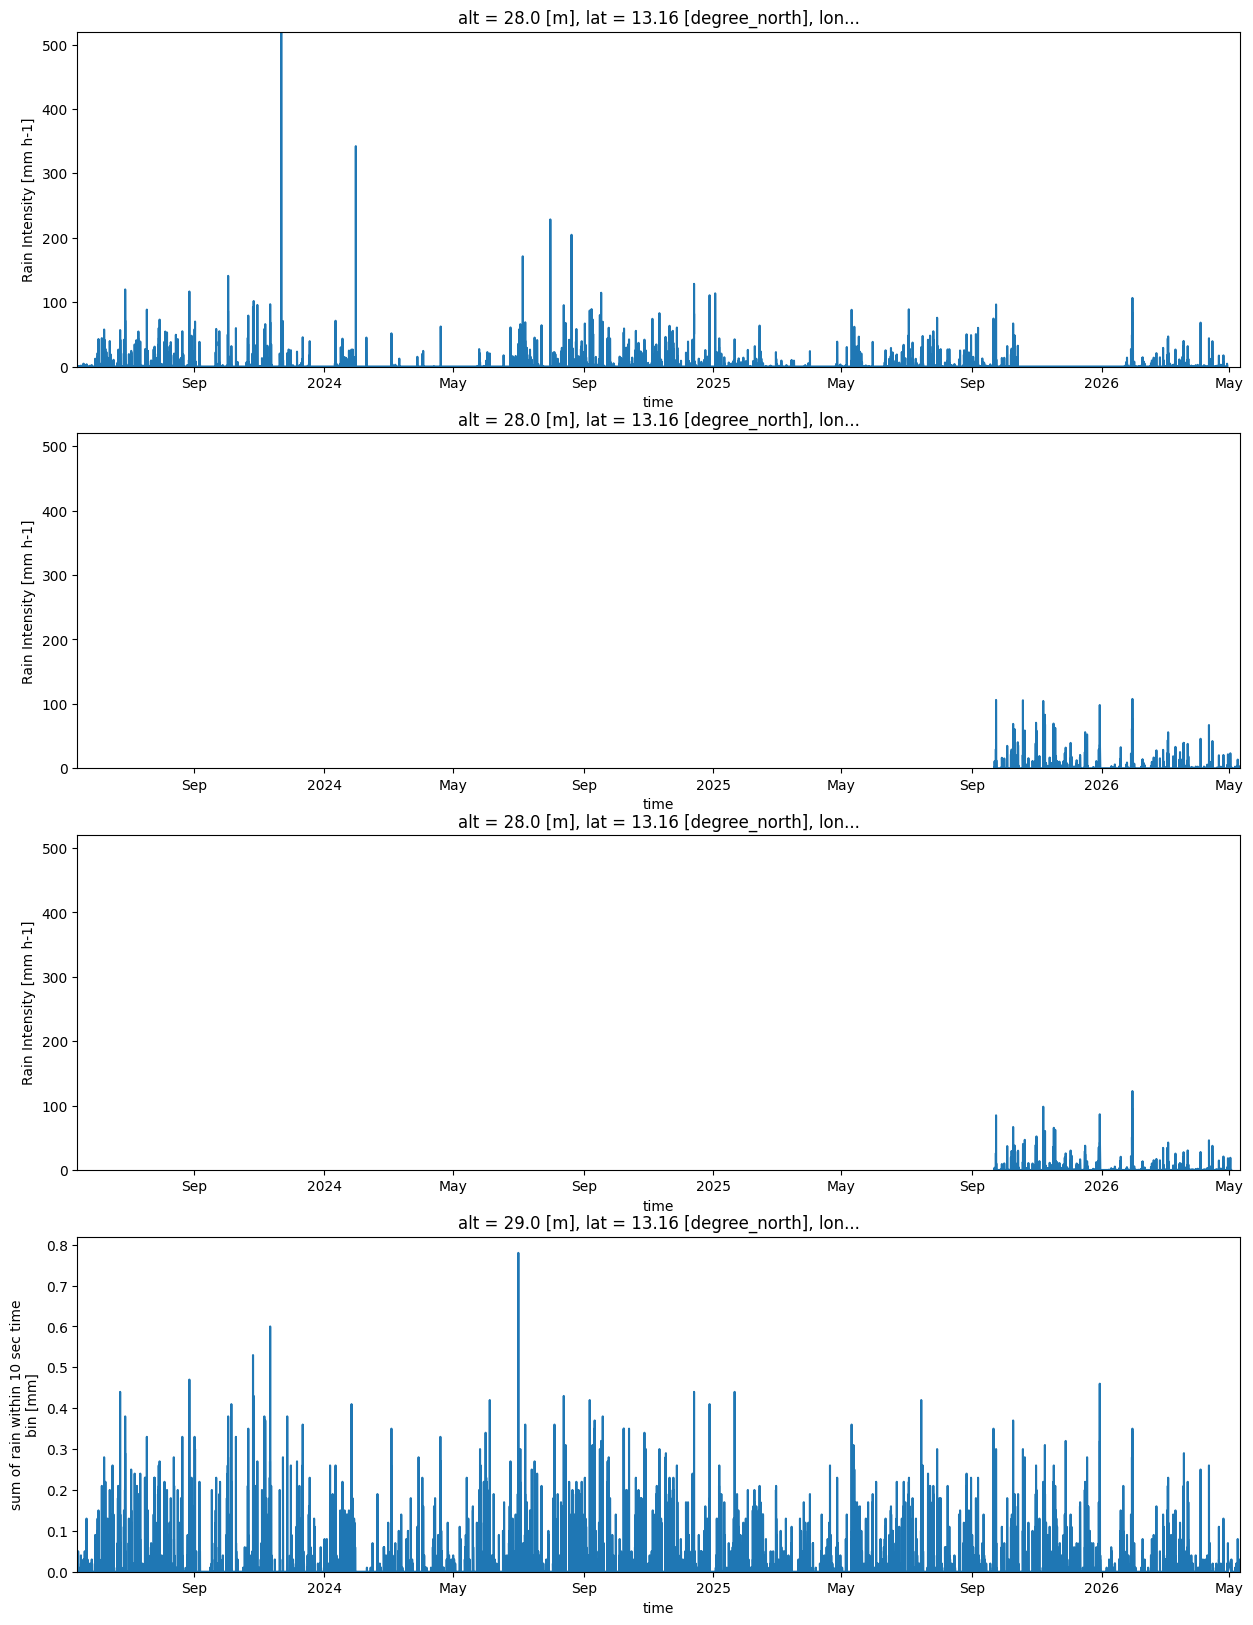

In [7]:
tmin, tmax = wxt_rain.time.min(), wxt_rain.time.max()

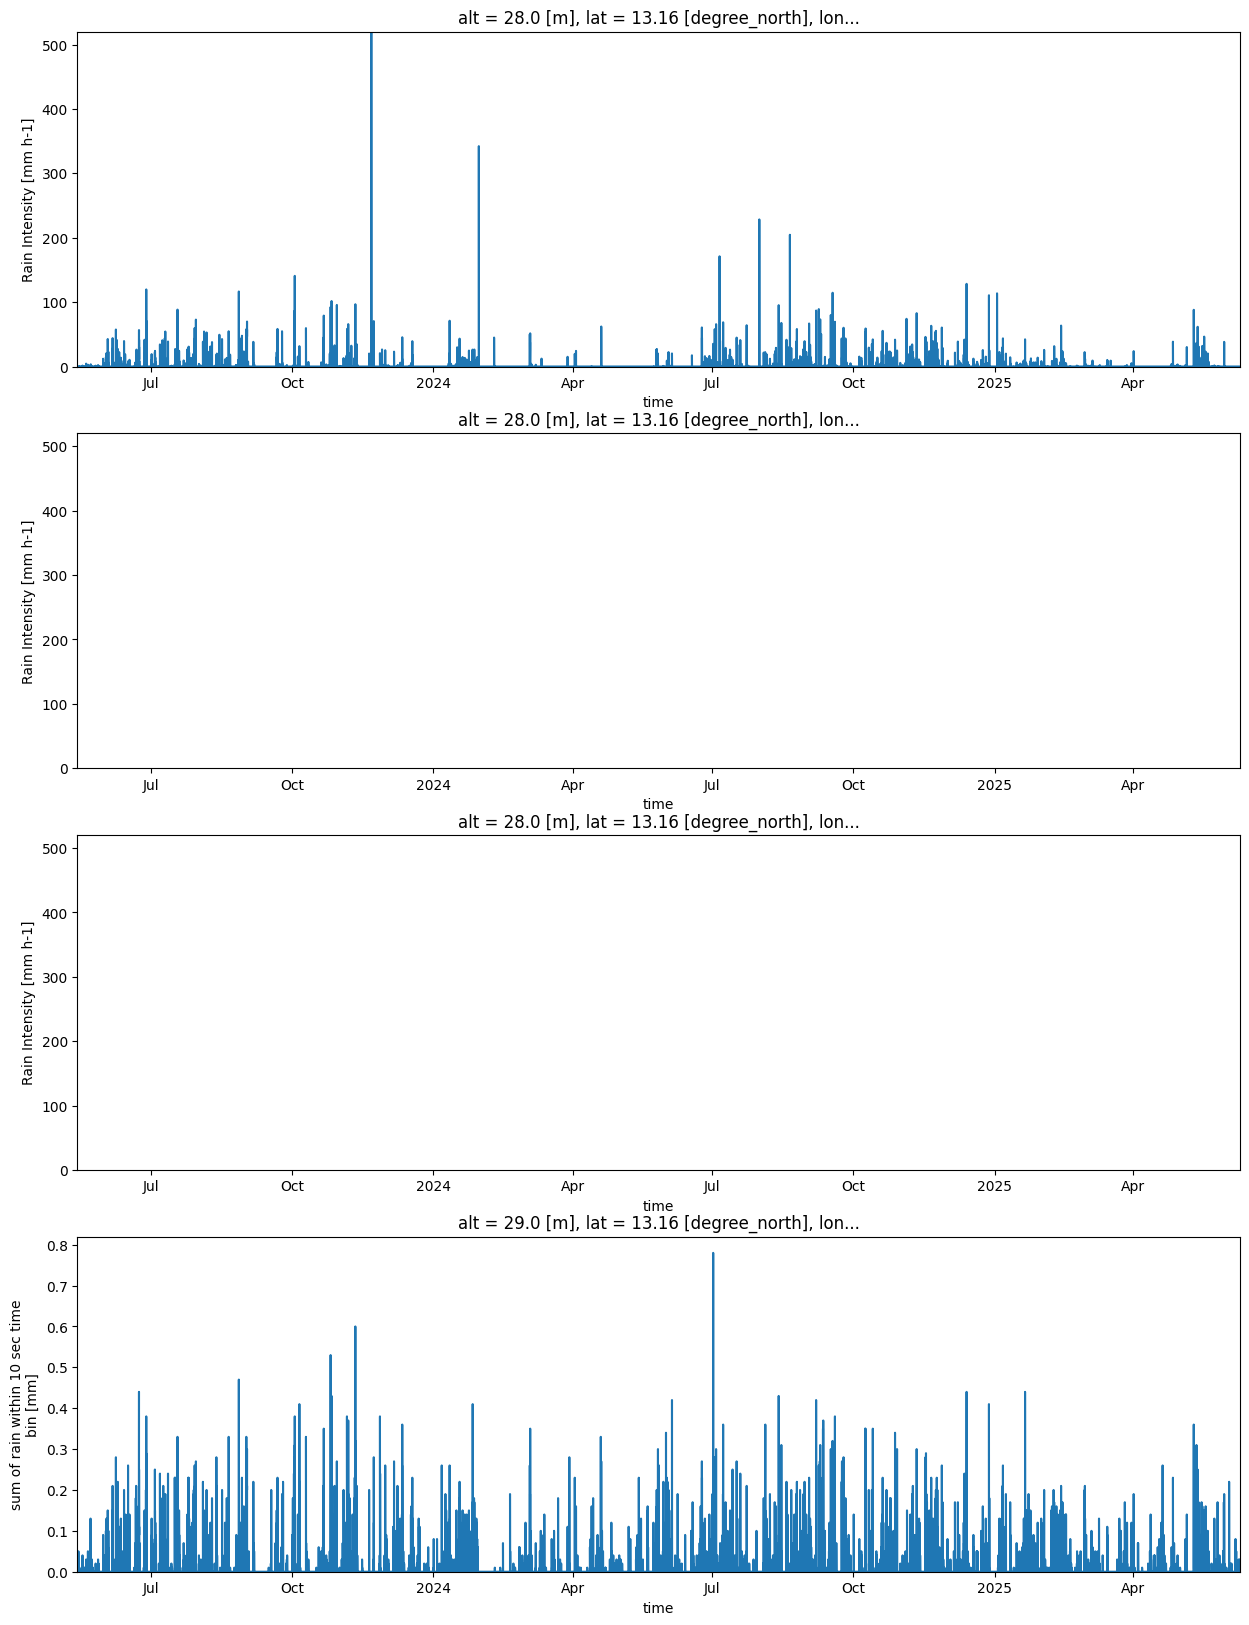

In [43]:
fig, axes = plt.subplots(4, 1, figsize=(15, 20))
ax1, ax2, ax3, ax4 = axes.flatten()
ds1_rain_rate.plot(ax=ax1, xlim=(tmin, tmax), ylim=(0, 520))
ds2_rain_rate.plot(ax=ax2, xlim=(tmin, tmax), ylim=(0, 520))
ds3_rain_rate.plot(ax=ax3, xlim=(tmin, tmax), ylim=(0, 520))
wxt_rain.plot(ax=ax4, xlim=(tmin, tmax), ylim=(0, None))

It would be interesting to see how the measurements from the different instruments line up. This will be done by investigating some rainfall events on Barbados from the Severe Weather Case Catalogue. We will consider the case of the tropical wave that affected Barbados on May 12th - 14th in 2025. The Grantley Adams International Airport recorded 72.39 mm on the 13th and 48.51 mm on the 14th.

## Converting Disdrometer Rain Rate to Hourly Accumulations
$$\mathrm{rainfall} = \sum(\mathrm{rain rate} \times \Delta t)$$

In [20]:
def compute_accumulated_rain(rain_rate, freq='1h'):
    """
    Convert rain rate (mm/hr) to accumulated rainfall (mm) at given frequency.
    Handles irregular time spacing.
    """
    # Δt in hours
    dt = rain_rate.time.diff('time') / np.timedelta64(1, 'h')

    # Align dimensions
    rain_rate_aligned = rain_rate.isel(time=slice(1, None))

    # Integrate
    rain_increment = rain_rate_aligned * dt

    # Resample
    return rain_increment.resample(time=freq).sum()

In [21]:
dis1_hourly_rainfall = compute_accumulated_rain(ds1_rain_rate, freq='1h')
dis2_hourly_rainfall = compute_accumulated_rain(ds2_rain_rate, freq='1h')
dis3_hourly_rainfall = compute_accumulated_rain(ds3_rain_rate, freq='1h')
wxt_hourly_rainfall = wxt_rain.resample(time='1h').sum()

### Event 1

In [22]:
event_start, event_end = '2025-05-12', '2025-05-14'

event1_ds1 = dis1_hourly_rainfall.sel(time=slice(event_start, event_end))
event1_wxt = wxt_hourly_rainfall.sel(time=slice(event_start, event_end))

event1_ds1_accumulation = event1_ds1.sum()
event1_wxt_accumulation = event1_wxt.sum()

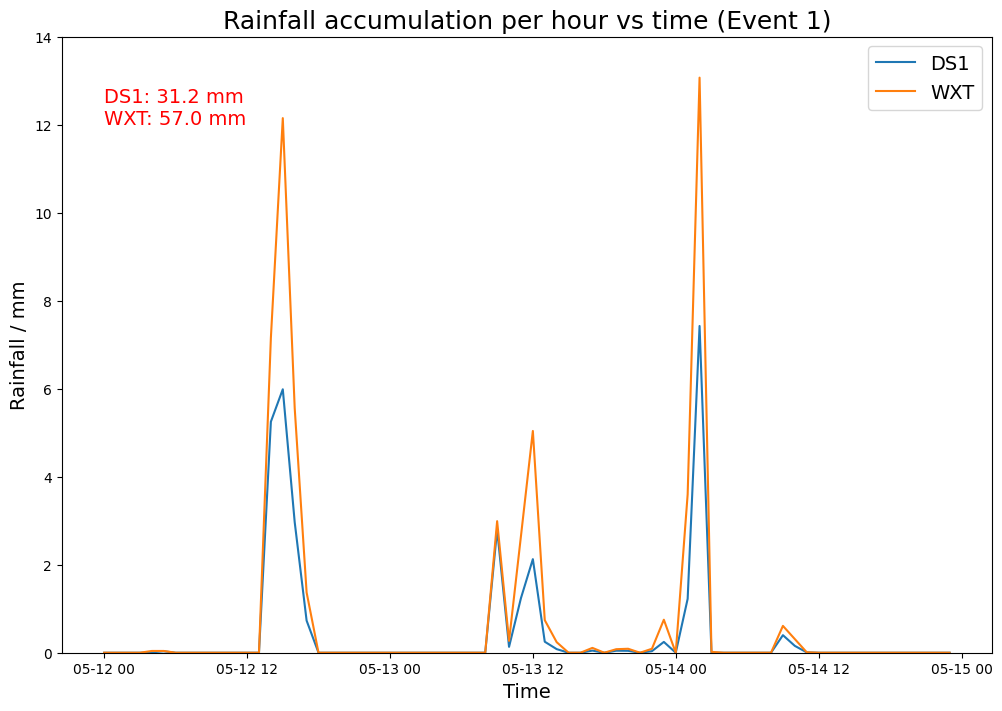

In [23]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(event1_ds1['time'], event1_ds1, label='DS1')
ax.plot(event1_wxt['time'], event1_wxt, label='WXT')
ax.text(
    x=np.datetime64(event_start),
    y=12,
    s=f"DS1: {event1_ds1_accumulation.values:.1f} mm\n"
    f"WXT: {event1_wxt_accumulation.values:.1f} mm",
    color='red',
    fontsize=14
)
ax.legend(loc='upper right', fontsize=14)
ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('Rainfall / mm', fontsize=14)
ax.set_ylim(0, 14)
ax.set_title('Rainfall accumulation per hour vs time (Event 1)', fontsize=18)

plt.show()

The disdrometer records rainfall at the same times at the wxt, however, it consistently underestimates it. We will look at another event which occurred on September 23-24 due to a passing tropical wave. This event should also have recordings from all four instruments.

### Event 2

In [24]:
event_start, event_end = '2025-09-23', '2025-09-24'

event2_ds1 = dis1_hourly_rainfall.sel(time=slice(event_start, event_end))
event2_ds2 = dis2_hourly_rainfall.sel(time=slice(event_start, event_end))
event2_ds3 = dis3_hourly_rainfall.sel(time=slice(event_start, event_end))
event2_wxt = wxt_hourly_rainfall.sel(time=slice(event_start, event_end))

event2_ds1_accumulation = event2_ds1.sum()
event2_ds2_accumulation = event2_ds2.sum()
event2_ds3_accumulation = event2_ds3.sum()
event2_wxt_accumulation = event2_wxt.sum()

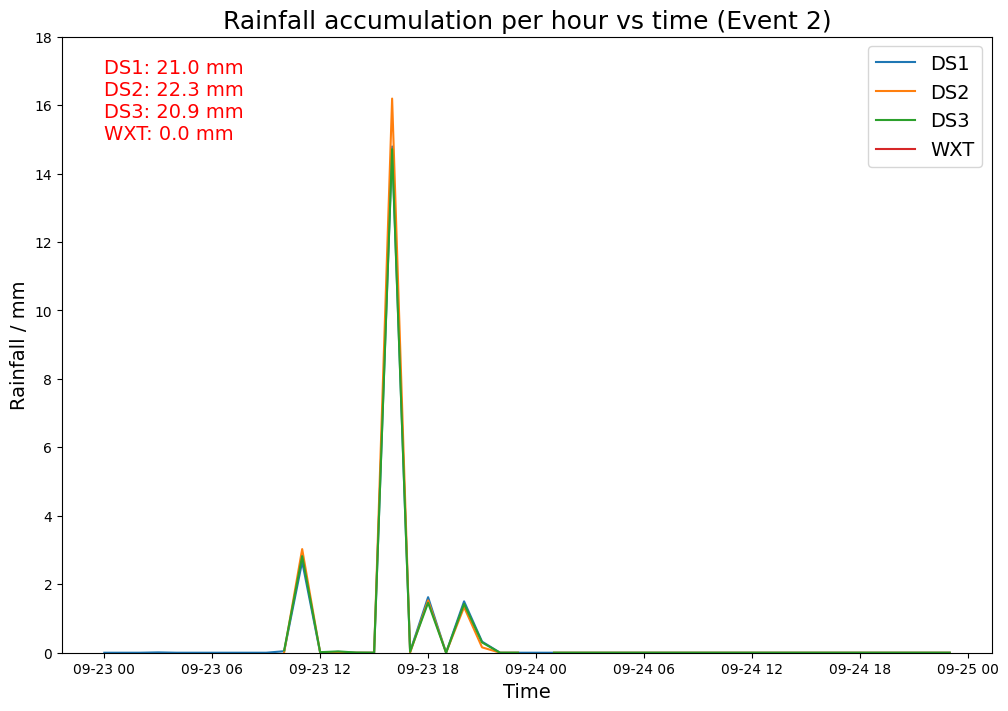

In [25]:
# titles = ["Disdrometer PARSIVEL451995_c1", "Disdrometer PARSIVEL451996_c1_v2", "Disdrometer PARSIVEL451997_c1_v2", 'WXT Surface Met Instrument']

fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(event2_ds1['time'], event2_ds1, label='DS1')
ax.plot(event2_ds2['time'], event2_ds2, label='DS2')
ax.plot(event2_ds3['time'], event2_ds3, label='DS3')
ax.plot(event2_wxt['time'], event2_wxt, label='WXT')

ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('Rainfall / mm', fontsize=14)
ax.set_ylim(0, 18)
ax.set_title('Rainfall accumulation per hour vs time (Event 2)', fontsize=18)

ax.text(
    x=np.datetime64(event_start),
    y=15,
    s=f"DS1: {event2_ds1_accumulation.values:.1f} mm\n"
      f"DS2: {event2_ds2_accumulation.values:.1f} mm\n"
      f"DS3: {event2_ds3_accumulation.values:.1f} mm\n"
      f"WXT: {event2_wxt_accumulation.values:.1f} mm",
    color='red',
    fontsize=14
)

ax.legend(loc='upper right', fontsize=14)

plt.show()

There is great alignment across all these instruments for this event.

We will not take a broader look at all the instruments.

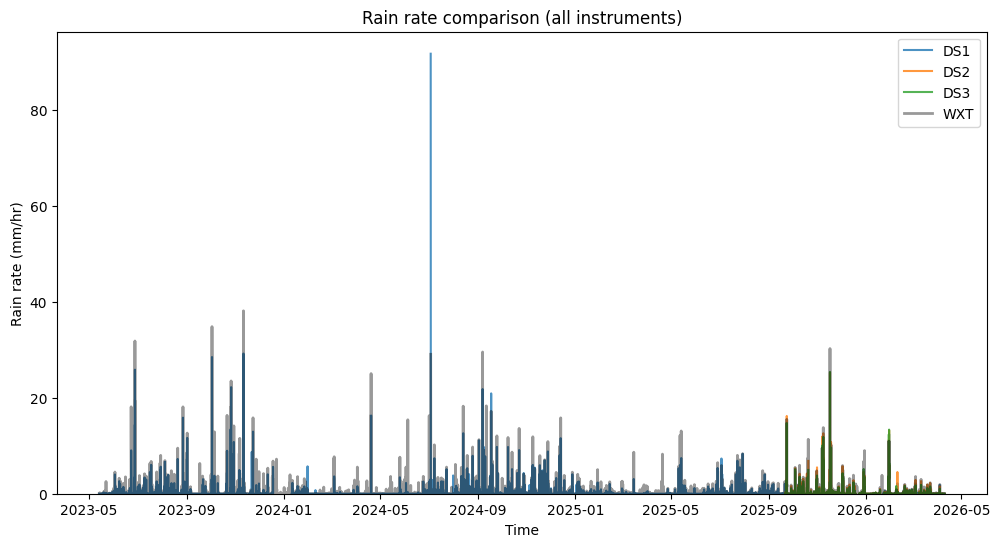

In [70]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(dis1_hourly_rainfall['time'], dis1_hourly_rainfall, label='DS1', alpha=0.8)
ax.plot(dis2_hourly_rainfall['time'], dis2_hourly_rainfall, label='DS2', alpha=0.8)
ax.plot(dis3_hourly_rainfall['time'], dis3_hourly_rainfall, label='DS3', alpha=0.8)
ax.plot(wxt_hourly_rainfall['time'], wxt_hourly_rainfall, label='WXT', alpha=0.4, linewidth=2, color='black')

ax.set(
    xlabel='Time',
    ylabel='Rain rate (mm/hr)',
    title='Rain rate comparison (all instruments)',
    ylim=(0, None)
)

ax.legend()
plt.show()

We will start by comparing the hourly rainfall accumulation measurements from the disdrometers with the WXT surfacemet.

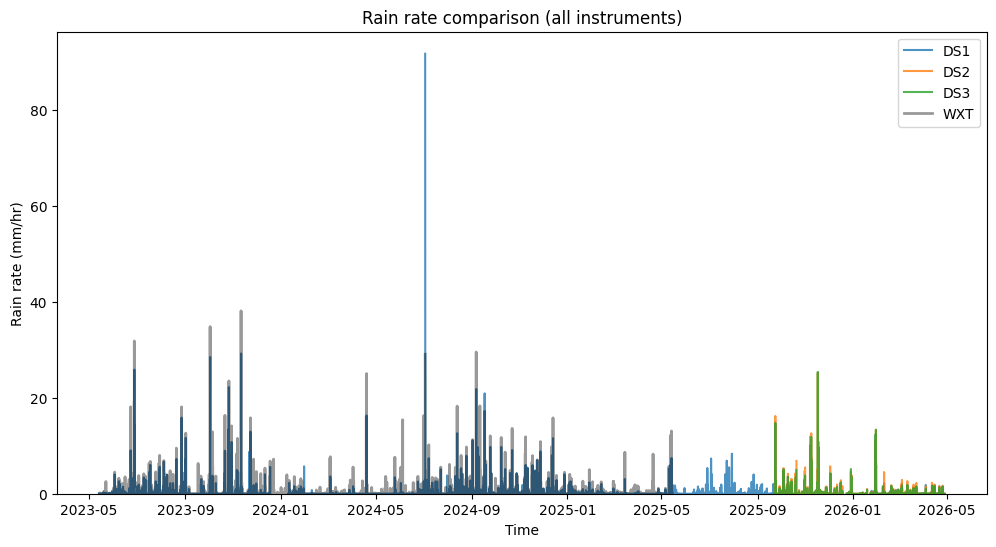

In [44]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(dis1_hourly_rainfall['time'], dis1_hourly_rainfall, label='DS1', alpha=0.8)
ax.plot(dis2_hourly_rainfall['time'], dis2_hourly_rainfall, label='DS2', alpha=0.8)
ax.plot(dis3_hourly_rainfall['time'], dis3_hourly_rainfall, label='DS3', alpha=0.8)
ax.plot(wxt_hourly_rainfall['time'], wxt_hourly_rainfall, label='WXT', alpha=0.4, linewidth=2, color='black')

ax.set(
    xlabel='Time',
    ylabel='Rain rate (mm/hr)',
    title='Rain rate comparison (all instruments)',
    ylim=(0, None)
)

ax.legend()
plt.show()

In [30]:
comparison_dataset_1 = xr.Dataset({
    'wxt': wxt_hourly_rainfall.reset_coords(drop=True),
    'dis1': dis1_hourly_rainfall.reset_coords(drop=True)
}
).dropna(dim='time')

comparison_dataset_2 = xr.Dataset({
    'wxt': wxt_hourly_rainfall.reset_coords(drop=True),
    'dis2': dis2_hourly_rainfall.reset_coords(drop=True)
}
).dropna(dim='time')

comparison_dataset_3 = xr.Dataset({
    'wxt': wxt_hourly_rainfall.reset_coords(drop=True),
    'dis3': dis3_hourly_rainfall.reset_coords(drop=True)
}
).dropna(dim='time')

comparison_dataset_4 = xr.Dataset({
    'dis2': dis2_hourly_rainfall.reset_coords(drop=True),
    'dis3': dis3_hourly_rainfall.reset_coords(drop=True)
}
).dropna(dim='time')

datasets = [comparison_dataset_1, comparison_dataset_2, comparison_dataset_3, comparison_dataset_4]

titles = [
    "WXT Surface Met and Disdrometer Parsivel 451995 v1",
    "WXT Surface Met and Disdrometer Parsivel 451995 v2",
    "WXT Surface Met and Disdrometer Parsivel 451995 v3",
    "Disdrometer Parsivel 451995 v2 and 451995 v3"
]

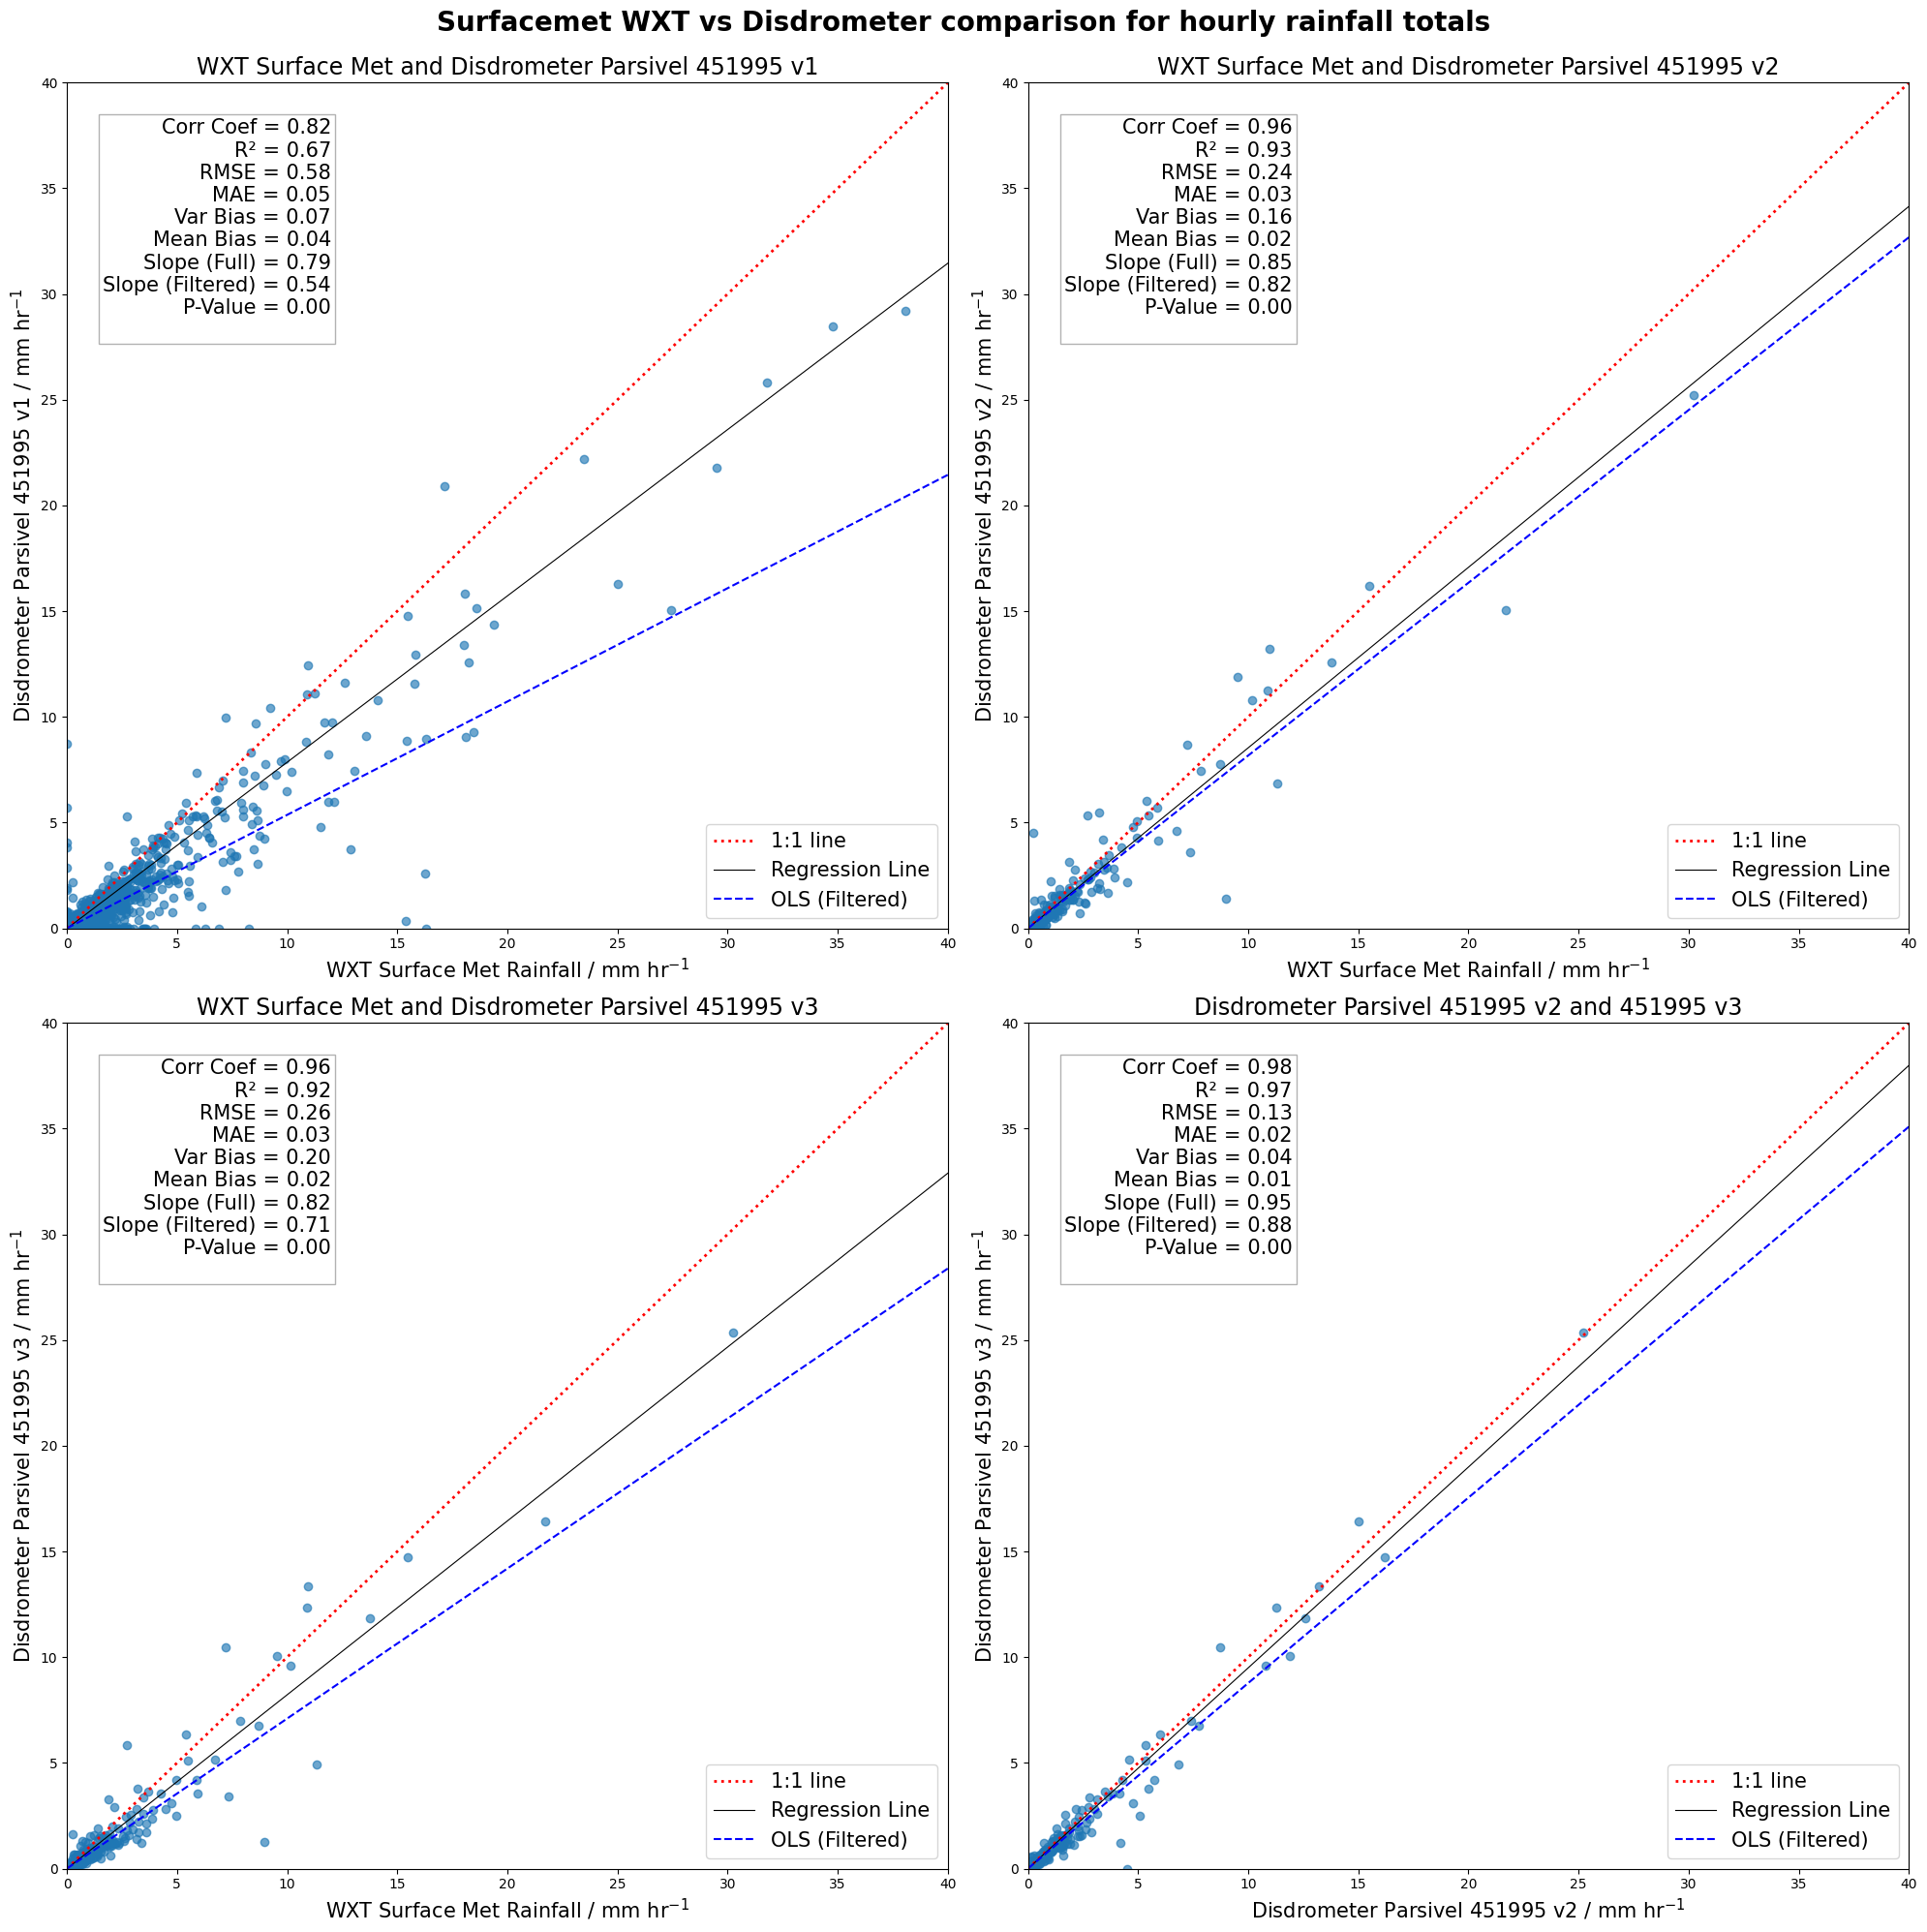

In [83]:
x = np.linspace(0, 40, 201)

fig, axes = plt.subplots(2, 2, figsize=(20, 20))
ax1, ax2, ax3, ax4 = axes.flatten()

for ax, dataset, title in zip(axes.flatten(), datasets, titles):
    # Extract variable names dynamically
    xvar, yvar = tuple(dataset.data_vars)

    # Statistics
    slope, intercept, rval, pval, stderr = linregress(dataset[xvar], dataset[yvar])
    cov_matrix = np.corrcoef(dataset[xvar], dataset[yvar])
    corr_coef = cov_matrix[0, 1]
    r2 = corr_coef ** 2
    mean_bias = np.mean(dataset[xvar] - dataset[yvar])
    variance_vias = np.var(dataset[xvar]) - np.var(dataset[yvar])
    rmse = np.sqrt(((dataset[xvar] - dataset[yvar]) ** 2).mean())
    mae = np.abs(dataset[xvar] - dataset[yvar]).mean()

    # --- Outlier filtering (top 1%) ---
    min_threshold = dataset[xvar].quantile(0.01)
    max_threshold = dataset[xvar].quantile(0.99)
    mask = (dataset[xvar] >= min_threshold) & (dataset[xvar] <= max_threshold)

    # Full regression
    slope_full, intercept_full, *_ = linregress(dataset[xvar], dataset[yvar])

    # Filtered regression
    slope_filtered, intercept_filtered, *_ = linregress(
        dataset[xvar][mask],
        dataset[yvar][mask]
    )

    stats_text = (
        f"Corr Coef = {corr_coef:.2f}\n"
        f"R² = {r2:.2f}\n"
        f"RMSE = {rmse:.2f}\n"
        f"MAE = {mae:.2f}\n"
        f"Var Bias = {variance_vias:.2f}\n"
        f"Mean Bias = {mean_bias:.2f}\n"
        f"Slope (Full) = {slope_full:.2f}\n"
        f"Slope (Filtered) = {slope_filtered:.2f}\n"
        f"P-Value = {pval:.2f}\n"
    )

    ax.text(x=12, y=28, s=stats_text, fontsize=15, bbox=dict(facecolor='white', edgecolor='gray', alpha=0.6, pad=3),
				horizontalalignment='right')

    ax.scatter(dataset[xvar], dataset[yvar], alpha=0.65)
    ax.plot(x, x, color='red', linestyle=':', linewidth=2, label='1:1 line')
    ax.plot(x, slope * x + intercept, color='black', linewidth=0.8, label='Regression Line')
    ax.plot(x, slope_filtered * x + intercept_filtered, color='blue', linestyle='--', linewidth=1.5, label='OLS (Filtered)')
    ax.set_title(title, fontsize=17)
    ax.set_xlim(0, 40)
    ax.set_ylim(0, 40)

    ax.legend(loc='lower right', fontsize=15)

ax1.set_xlabel(r'WXT Surface Met Rainfall / mm hr$^{-1}$', fontsize=15)
ax1.set_ylabel(r'Disdrometer Parsivel 451995 v1 / mm hr$^{-1}$', fontsize=15)
ax2.set_xlabel(r'WXT Surface Met Rainfall / mm hr$^{-1}$', fontsize=15)
ax2.set_ylabel(r'Disdrometer Parsivel 451995 v2 / mm hr$^{-1}$', fontsize=15)
ax3.set_xlabel(r'WXT Surface Met Rainfall / mm hr$^{-1}$', fontsize=15)
ax3.set_ylabel(r'Disdrometer Parsivel 451995 v3 / mm hr$^{-1}$', fontsize=15)
ax4.set_xlabel(r'Disdrometer Parsivel 451995 v2 / mm hr$^{-1}$', fontsize=15)
ax4.set_ylabel(r'Disdrometer Parsivel 451995 v3 / mm hr$^{-1}$', fontsize=15)

fig.suptitle("Surfacemet WXT vs Disdrometer comparison for hourly rainfall totals", y=0.995, fontweight='heavy', fontsize=20)
fig.tight_layout()

plt.show()

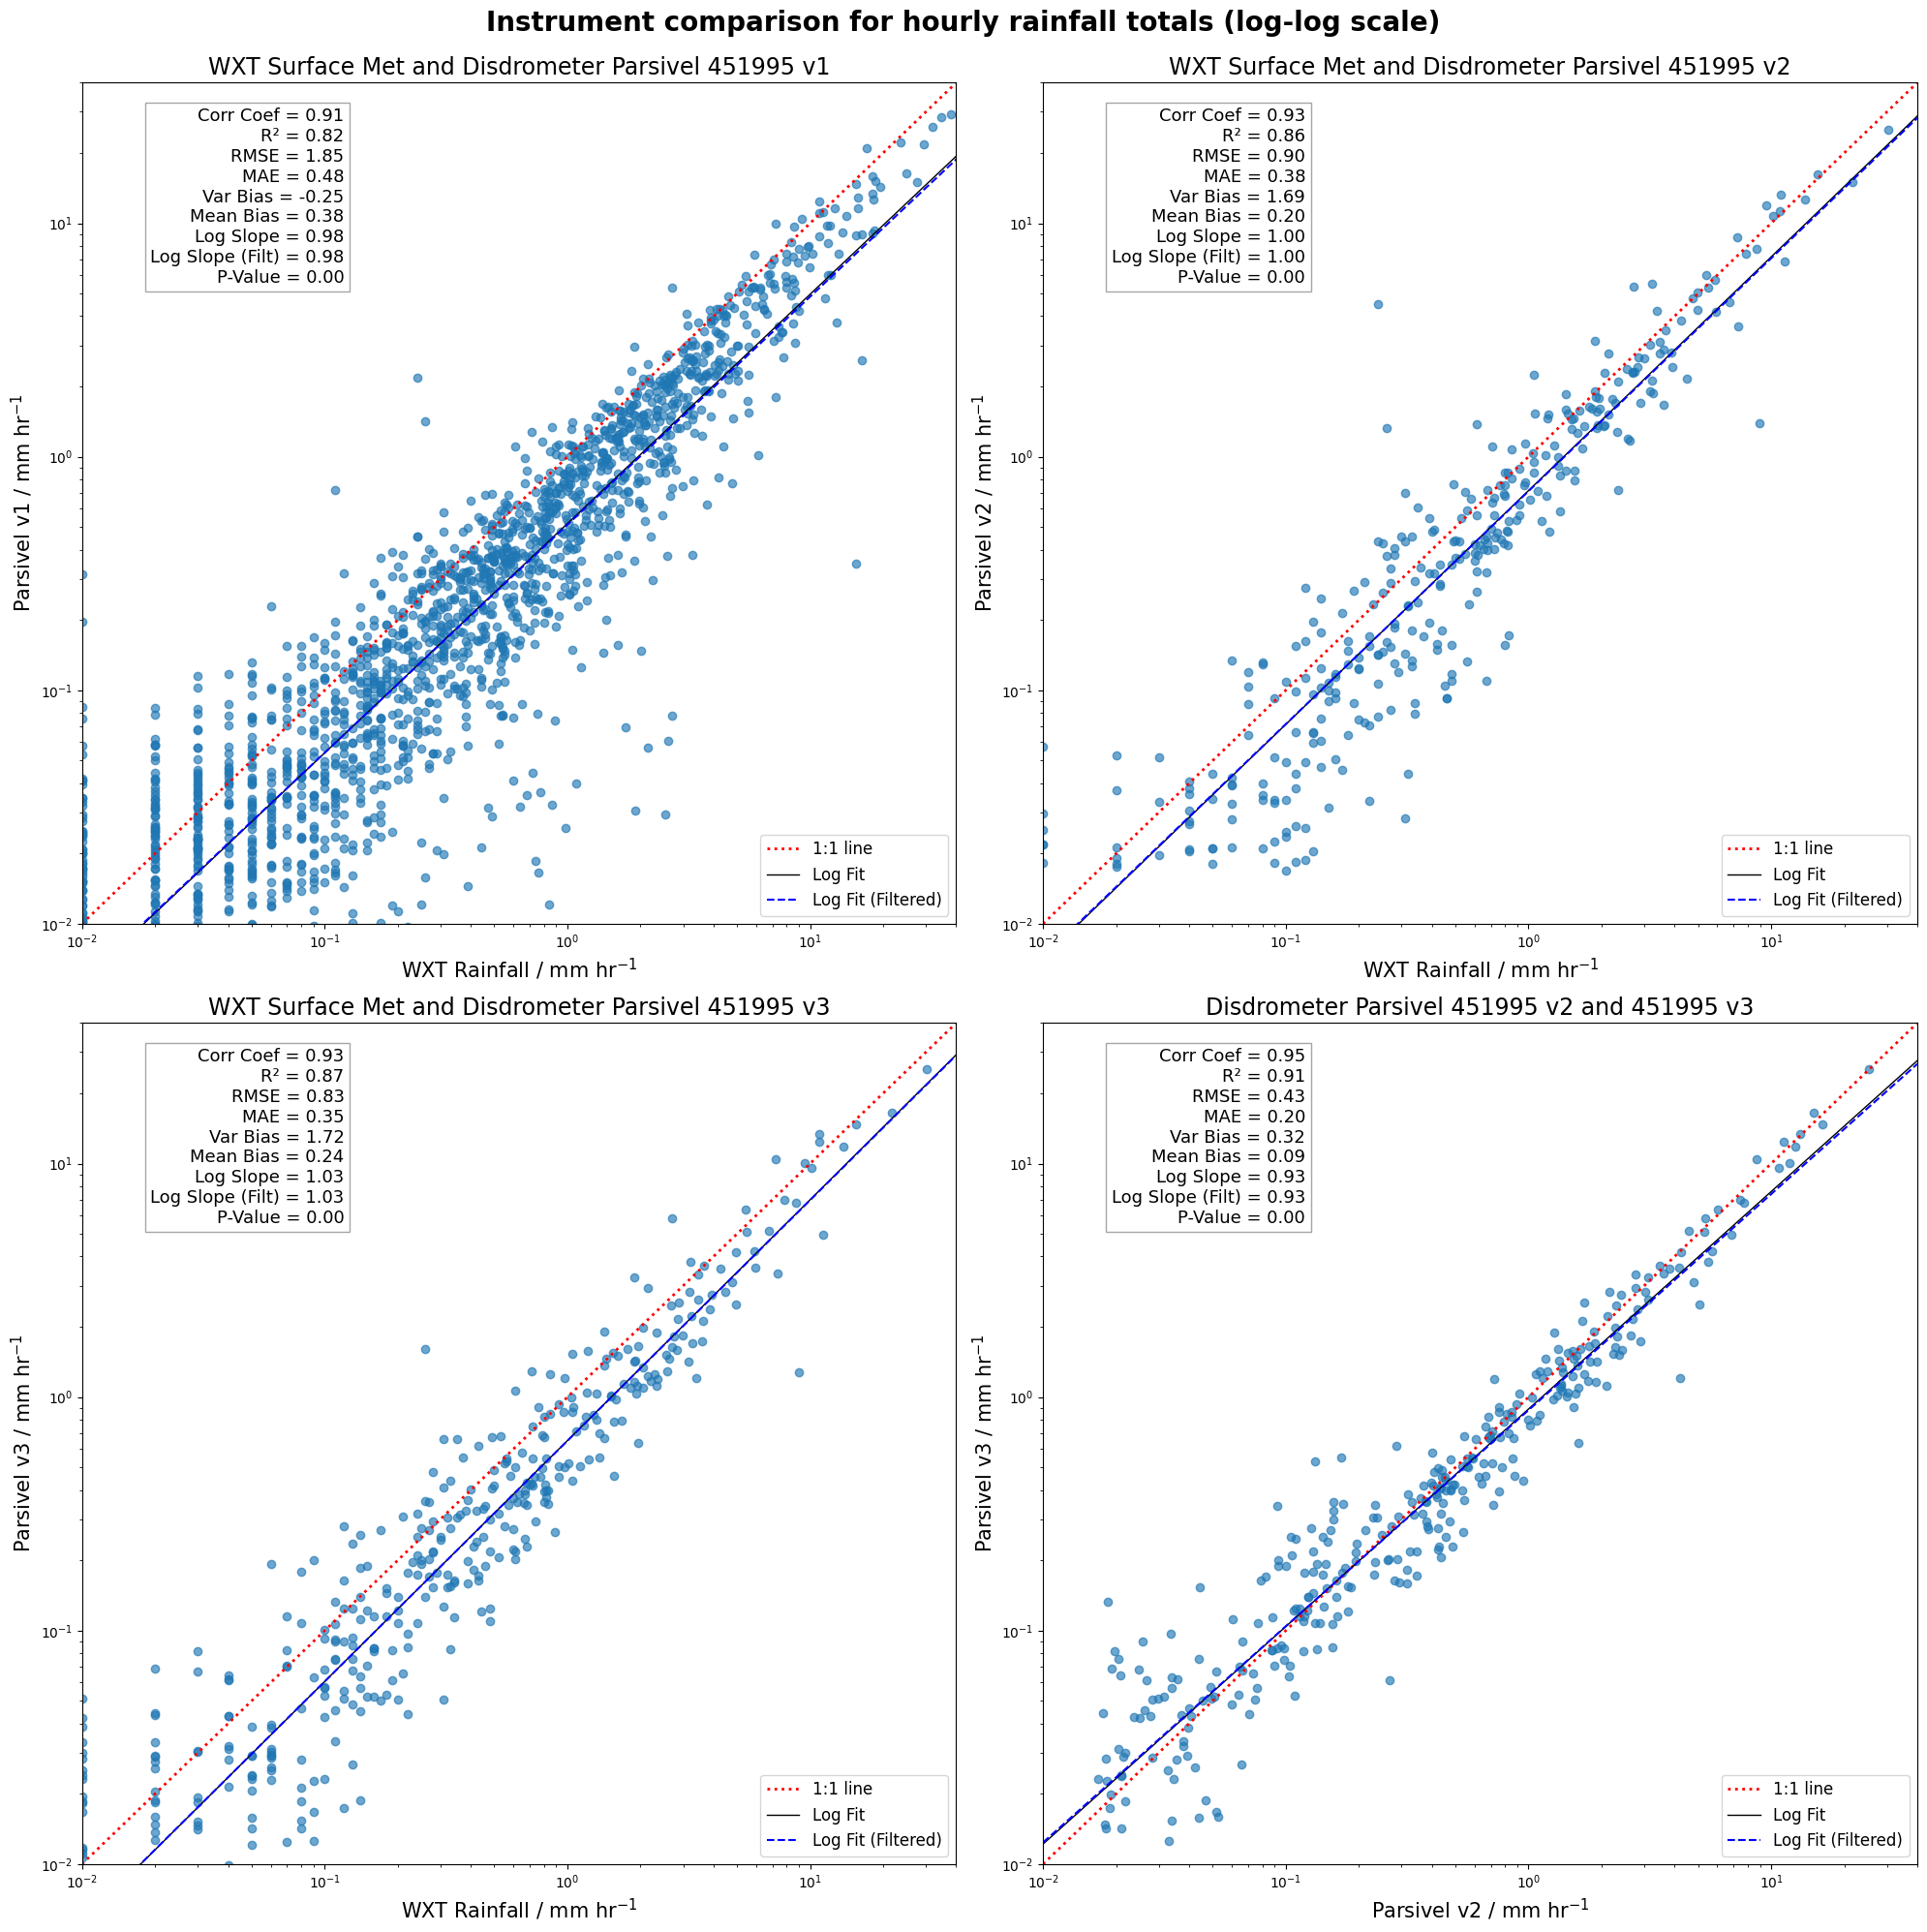

In [17]:
x = np.logspace(-2, np.log10(40), 300)   # from 0.01 to 40

fig, axes = plt.subplots(2, 2, figsize=(20, 20))
ax1, ax2, ax3, ax4 = axes.flatten()

for ax, dataset, title in zip(axes.flatten(), datasets, titles):
    # Extract variable names dynamically
    xvar, yvar = tuple(dataset.data_vars)

    # raw arrays
    xdata = dataset[xvar].values
    ydata = dataset[yvar].values

    # keep only finite positive values for log scale
    valid = np.isfinite(xdata) & np.isfinite(ydata) & (xdata > 0) & (ydata > 0)

    xdata = xdata[valid]
    ydata = ydata[valid]

    # Regression in log10 space
    logx = np.log10(xdata)
    logy = np.log10(ydata)

    slope, intercept, rval, pval, stderr = linregress(logx, logy)

    corr_coef = np.corrcoef(logx, logy)[0, 1]
    r2 = corr_coef**2
    rmse = np.sqrt(np.mean((ydata - xdata)**2))
    mae = np.mean(np.abs(ydata - xdata))
    mean_bias = np.mean(xdata - ydata)
    variance_vias = np.var(xdata) - np.var(ydata)

    # Filter central 98% in x (still in original units)
    min_threshold = np.quantile(xdata, 0.00)
    max_threshold = np.quantile(xdata, 0.99)

    mask = (xdata >= min_threshold) & (xdata <= max_threshold)

    logx_f = np.log10(xdata[mask])
    logy_f = np.log10(ydata[mask])

    slope_filtered, intercept_filtered, *_ = linregress(logx_f, logy_f)

    stats_text = (
        f"Corr Coef = {corr_coef:.2f}\n"
        f"R² = {r2:.2f}\n"
        f"RMSE = {rmse:.2f}\n"
        f"MAE = {mae:.2f}\n"
        f"Var Bias = {variance_vias:.2f}\n"
        f"Mean Bias = {mean_bias:.2f}\n"
        f"Log Slope = {slope:.2f}\n"
        f"Log Slope (Filt) = {slope_filtered:.2f}\n"
        f"P-Value = {pval:.2f}"
    )

    ax.text(
        0.3, 0.97, stats_text,
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=13,
        bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7)
    )

    # scatter
    ax.scatter(xdata, ydata, alpha=0.65)

    # 1:1 line
    ax.plot(x, x, color='red', linestyle=':', linewidth=2, label='1:1 line')

    # back-transform regression: y = 10^intercept * x^slope
    yfit = 10**intercept * x**slope
    yfit_f = 10**intercept_filtered * x**slope_filtered

    ax.plot(x, yfit, color='black', linewidth=1.0, label='Log Fit')
    ax.plot(x, yfit_f, color='blue', linestyle='--', linewidth=1.5, label='Log Fit (Filtered)')

    # log axes
    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlim(0.01, 40)
    ax.set_ylim(0.01, 40)

    ax.set_title(title, fontsize=17)
    ax.legend(loc='lower right', fontsize=12)

# labels
ax1.set_xlabel(r'WXT Rainfall / mm hr$^{-1}$', fontsize=15)
ax1.set_ylabel(r'Parsivel v1 / mm hr$^{-1}$', fontsize=15)

ax2.set_xlabel(r'WXT Rainfall / mm hr$^{-1}$', fontsize=15)
ax2.set_ylabel(r'Parsivel v2 / mm hr$^{-1}$', fontsize=15)

ax3.set_xlabel(r'WXT Rainfall / mm hr$^{-1}$', fontsize=15)
ax3.set_ylabel(r'Parsivel v3 / mm hr$^{-1}$', fontsize=15)

ax4.set_xlabel(r'Parsivel v2 / mm hr$^{-1}$', fontsize=15)
ax4.set_ylabel(r'Parsivel v3 / mm hr$^{-1}$', fontsize=15)

fig.suptitle(
    "Instrument comparison for hourly rainfall totals (log-log scale)",
    y=0.995, fontweight='heavy', fontsize=20
)

fig.tight_layout()
plt.show()

# Investigation for rain rates above $20 \,\mathrm{mm h}^{-1}$
We now isolate wxt measurements above $20 \,\mathrm{mm h}^{-1}$ and compare the instantaneous measurements

In [14]:
time_slice = slice('2023-05-14T00:46:28', datetime.now())

ds1_rain_rate = ds1['rain_rate'].sel(time=time_slice).compute()
ds2_rain_rate = ds2['rain_rate'].sel(time=time_slice).compute()
ds3_rain_rate = ds3['rain_rate'].sel(time=time_slice).compute()

wxt_ri = wxt["RI"].sel(time=time_slice).compute()
wxt_ri_above_20 = wxt_ri.where(wxt_ri > 20, drop=True)

In [27]:
def build_dataset(wxt, dis, method='exact', tolerance=None):
    if method == 'exact':
        # Strict timestamp match
        wxt_aligned, dis_aligned = xr.align(wxt, dis, join='inner')

    elif method == 'nearest':
        # Match disdrometer to WXT timestamps
        dis_aligned = dis.sel(
            time=wxt.time,
            method='nearest',
            tolerance=tolerance
        )
        wxt_aligned, dis_aligned = xr.align(wxt, dis_aligned, join='inner')

    elif method == 'interp':
        # Interpolate disdrometer onto WXT time grid
        dis_aligned = dis.interp(time=wxt.time)
        wxt_aligned, dis_aligned = xr.align(wxt, dis_aligned, join='inner')

    else:
        raise ValueError("method must be 'exact', 'nearest', or 'interp'")

    # Apply WXT > 20 condition
    mask = wxt_aligned > 20

    wxt_sel = wxt_aligned.where(mask, drop=True)
    dis_sel = dis_aligned.where(mask, drop=True)

    return xr.Dataset({
        'wxt': wxt_sel,
        'dis': dis_sel
    }).dropna(dim='time')

In [28]:
comparison_dataset_1 = build_dataset(wxt_ri, ds1_rain_rate, method='interp', tolerance=10)
comparison_dataset_2 = build_dataset(wxt_ri, ds2_rain_rate, method='interp', tolerance=10)
comparison_dataset_3 = build_dataset(wxt_ri, ds3_rain_rate, method='interp', tolerance=10)

datasets = [comparison_dataset_1, comparison_dataset_2, comparison_dataset_3]

titles = [
    "WXT instantaneous rain rate above 20 mm/hr vs Disdrometer Parsivel 451995 v1",
    "WXT instantaneous rain rate above 20 mm/hr vs Parsivel 451995 v2",
    "WXT instantaneous rain rate above 20 mm/hr vs Disdrometer Parsivel 451995 v3"
]

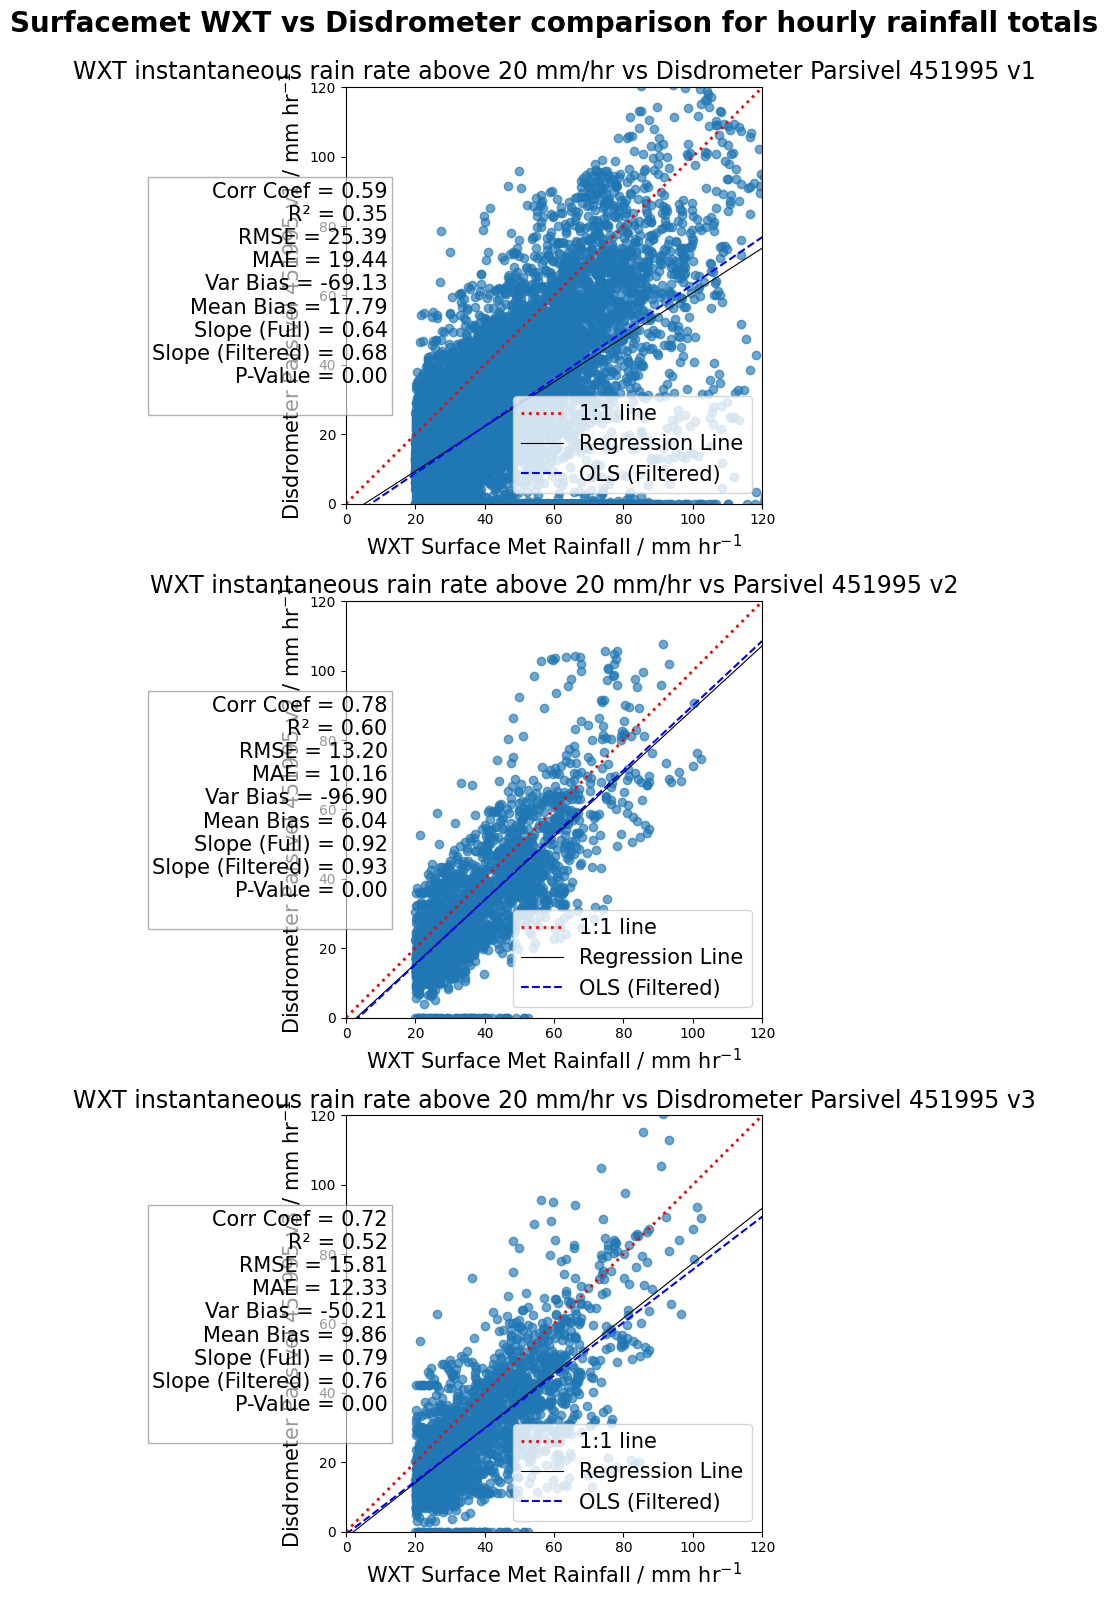

In [18]:
x = np.linspace(0, 120, 201)

fig, axes = plt.subplots(3, 1, figsize=(10, 16))
ax1, ax2, ax3 = axes.flatten()

for ax, dataset, title in zip(axes.flatten(), datasets, titles):
    # Extract variable names dynamically
    xvar, yvar = tuple(dataset.data_vars)

    # Statistics
    slope, intercept, rval, pval, stderr = linregress(dataset[xvar], dataset[yvar])
    cov_matrix = np.corrcoef(dataset[xvar], dataset[yvar])
    corr_coef = cov_matrix[0, 1]
    r2 = corr_coef ** 2
    mean_bias = np.mean(dataset[xvar] - dataset[yvar])
    variance_vias = np.var(dataset[xvar]) - np.var(dataset[yvar])
    rmse = np.sqrt(((dataset[xvar] - dataset[yvar]) ** 2).mean())
    mae = np.abs(dataset[xvar] - dataset[yvar]).mean()

    # --- Outlier filtering (top 1%) ---
    min_threshold = dataset[xvar].quantile(0.01)
    max_threshold = dataset[xvar].quantile(0.99)
    mask = (dataset[xvar] >= min_threshold) & (dataset[xvar] <= max_threshold)

    # Full regression
    slope_full, intercept_full, *_ = linregress(dataset[xvar], dataset[yvar])

    # Filtered regression
    slope_filtered, intercept_filtered, *_ = linregress(
        dataset[xvar][mask],
        dataset[yvar][mask]
    )

    stats_text = (
        f"Corr Coef = {corr_coef:.2f}\n"
        f"R² = {r2:.2f}\n"
        f"RMSE = {rmse:.2f}\n"
        f"MAE = {mae:.2f}\n"
        f"Var Bias = {variance_vias:.2f}\n"
        f"Mean Bias = {mean_bias:.2f}\n"
        f"Slope (Full) = {slope_full:.2f}\n"
        f"Slope (Filtered) = {slope_filtered:.2f}\n"
        f"P-Value = {pval:.2f}\n"
    )

    ax.text(x=12, y=28, s=stats_text, fontsize=15, bbox=dict(facecolor='white', edgecolor='gray', alpha=0.6, pad=3),
				horizontalalignment='right')

    ax.scatter(dataset[xvar], dataset[yvar], alpha=0.65)
    ax.plot(x, x, color='red', linestyle=':', linewidth=2, label='1:1 line')
    ax.plot(x, slope * x + intercept, color='black', linewidth=0.8, label='Regression Line')
    ax.set_xlabel(r'WXT Surface Met Rainfall / mm hr$^{-1}$', fontsize=15)
    ax.set_title(title, fontsize=17)
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 120)

    ax.legend(loc='lower right', fontsize=15)

    ax.set_aspect('equal')


ax1.set_ylabel(r'Disdrometer Parsivel 451995 v1 / mm hr$^{-1}$', fontsize=15)
ax2.set_ylabel(r'Disdrometer Parsivel 451995 v2 / mm hr$^{-1}$', fontsize=15)
ax3.set_ylabel(r'Disdrometer Parsivel 451995 v3 / mm hr$^{-1}$', fontsize=15)

fig.suptitle("Surfacemet WXT vs Disdrometer comparison for hourly rainfall totals", y=0.995, fontweight='heavy', fontsize=20)
fig.tight_layout()

plt.show()

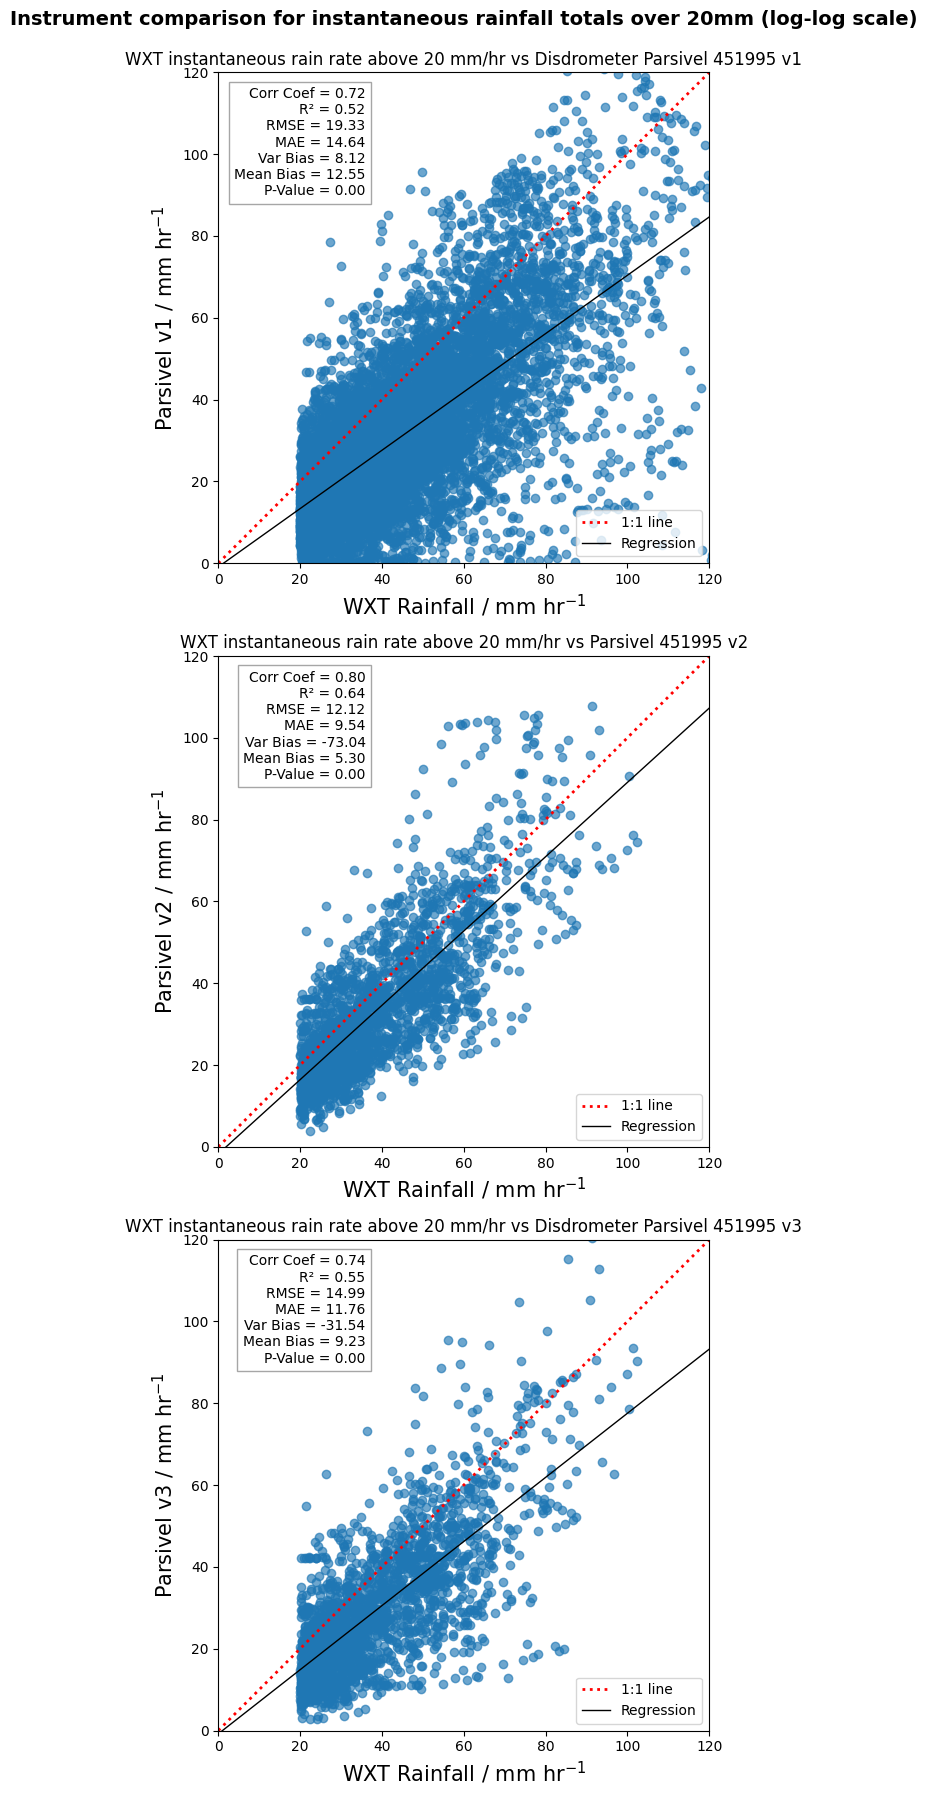

In [52]:
comparison_dataset_1 = build_dataset(wxt_ri, ds1_rain_rate, method='nearest', tolerance=10)
comparison_dataset_2 = build_dataset(wxt_ri, ds2_rain_rate, method='nearest', tolerance=10)
comparison_dataset_3 = build_dataset(wxt_ri, ds3_rain_rate, method='nearest', tolerance=10)

datasets = [comparison_dataset_1, comparison_dataset_2, comparison_dataset_3]

titles = [
    "WXT instantaneous rain rate above 20 mm/hr vs Disdrometer Parsivel 451995 v1",
    "WXT instantaneous rain rate above 20 mm/hr vs Parsivel 451995 v2",
    "WXT instantaneous rain rate above 20 mm/hr vs Disdrometer Parsivel 451995 v3"
]

In [7]:
comparison_dataset_1 = build_dataset(wxt_ri, ds1_rain_rate, method='interp', tolerance=10)
comparison_dataset_2 = build_dataset(wxt_ri, ds2_rain_rate, method='interp', tolerance=10)
comparison_dataset_3 = build_dataset(wxt_ri, ds3_rain_rate, method='interp', tolerance=10)

datasets = [comparison_dataset_1, comparison_dataset_2, comparison_dataset_3]

titles = [
    "WXT instantaneous rain rate above 20 mm/hr vs Disdrometer Parsivel 451995 v1",
    "WXT instantaneous rain rate above 20 mm/hr vs Parsivel 451995 v2",
    "WXT instantaneous rain rate above 20 mm/hr vs Disdrometer Parsivel 451995 v3"
]